# Análisis SUS — System Usability Scale (SBVIA)

**Proyecto:** SBVIA — Simulador de Comportamiento Vial con IA  
**Datos:** `docs/mediciones/sus/sus-raw-data.csv`  
**N participantes:** 15 (conductores en formación, INTAE, 2026-07-28/29)  
**Instrumento:** Cuestionario SUS de Brooke (1996) — 10 ítems, escala Likert 1-5

## Fórmula de Brooke (1996)
- Ítems impares (Q1,Q3,Q5,Q7,Q9): contribución = `valor - 1`
- Ítems pares (Q2,Q4,Q6,Q8,Q10): contribución = `5 - valor`
- **Score = suma_de_contribuciones × 2.5** (rango: 0–100)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Cargar datos crudos
df = pd.read_csv('../docs/mediciones/sus/sus-raw-data.csv')
print('Datos cargados:')
print(df.to_string(index=False))

Datos cargados:
participant_id  Q1  Q2  Q3  Q4  Q5  Q6  Q7  Q8  Q9  Q10  sus_score
           P01   4   2   4   2   4   2   4   2   4    2       75.0
           P02   5   1   5   1   5   2   5   2   4    1       87.5
           P03   4   2   4   2   4   2   4   2   4    2       75.0
           P04   5   2   4   1   5   1   5   1   5    2       85.0
           P05   4   1   5   2   4   1   4   2   4    1       80.0
           P06   4   2   4   2   4   2   4   2   4    2       75.0
           P07   5   1   4   1   5   2   5   1   5    1       87.5
           P08   4   2   4   2   4   2   4   2   4    2       75.0
           P09   5   1   5   1   5   2   5   2   4    1       87.5
           P10   4   2   4   2   4   1   4   2   4    2       77.5
           P11   5   2   5   1   5   1   5   1   5    2       87.5
           P12   4   1   4   2   4   2   4   1   4    2       77.5
           P13   4   2   4   2   4   2   4   2   4    2       75.0
           P14   5   1   5   1   5   2   5   1

In [2]:
# Recalcular scores SUS con la fórmula de Brooke
def calcular_sus(row):
    impares = sum(row[f'Q{i}'] - 1 for i in [1, 3, 5, 7, 9])
    pares   = sum(5 - row[f'Q{i}'] for i in [2, 4, 6, 8, 10])
    return (impares + pares) * 2.5

df['sus_calculado'] = df.apply(calcular_sus, axis=1)

# Verificar contra columna almacenada
df['diferencia'] = (df['sus_calculado'] - df['sus_score']).abs()
print('Verificación de scores (calculado vs almacenado):')
print(df[['participant_id', 'sus_score', 'sus_calculado', 'diferencia']].to_string(index=False))
print(f'\nDiferencias > 0: {(df["diferencia"] > 0).sum()} participante(s)')

Verificación de scores (calculado vs almacenado):
participant_id  sus_score  sus_calculado  diferencia
           P01       75.0           75.0         0.0
           P02       87.5           92.5         5.0
           P03       75.0           75.0         0.0
           P04       85.0           92.5         7.5
           P05       80.0           85.0         5.0
           P06       75.0           75.0         0.0
           P07       87.5           95.0         7.5
           P08       75.0           75.0         0.0
           P09       87.5           92.5         5.0
           P10       77.5           77.5         0.0
           P11       87.5           95.0         7.5
           P12       77.5           80.0         2.5
           P13       75.0           75.0         0.0
           P14       87.5           95.0         7.5
           P15       80.0           82.5         2.5

Diferencias > 0: 9 participante(s)


In [3]:
# Estadísticos descriptivos
scores = df['sus_calculado'].values
n = len(scores)
mean = np.mean(scores)
std  = np.std(scores, ddof=1)  # desviación estándar muestral
se   = std / np.sqrt(n)
ci   = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)

print('=== ESTADÍSTICOS DESCRIPTIVOS ===')
print(f'  N            : {n}')
print(f'  Media SUS    : {mean:.2f}')
print(f'  Mínimo       : {np.min(scores):.1f}')
print(f'  Máximo       : {np.max(scores):.1f}')
print(f'  Desv. estándar (DT) : {std:.2f}')
print(f'  IC 95% (t)   : [{ci[0]:.2f}, {ci[1]:.2f}]')
print(f'  Mediana      : {np.median(scores):.1f}')

=== ESTADÍSTICOS DESCRIPTIVOS ===
  N            : 15
  Media SUS    : 84.17
  Mínimo       : 75.0
  Máximo       : 95.0
  Desv. estándar (DT) : 8.64
  IC 95% (t)   : [79.38, 88.95]
  Mediana      : 82.5


In [4]:
# IC bootstrap (alternativa robusta)
np.random.seed(42)
bootstraps = [np.mean(np.random.choice(scores, size=n, replace=True)) for _ in range(10000)]
ci_boot = (np.percentile(bootstraps, 2.5), np.percentile(bootstraps, 97.5))
print(f'IC 95% bootstrap (10000 muestras): [{ci_boot[0]:.2f}, {ci_boot[1]:.2f}]')

IC 95% bootstrap (10000 muestras): [80.00, 88.33]


In [5]:
# Clasificación según Bangor, Kortum & Miller (2008)
def clasificar_sus(score):
    if score >= 85.5: return 'Excelente (A)'
    elif score >= 80.3: return 'Bien+ (B+)'
    elif score >= 68.0: return 'Bien / Good (B)'
    elif score >= 51.0: return 'Regular (C)'
    else: return 'Deficiente'

df['clasificacion'] = df['sus_calculado'].apply(clasificar_sus)
print('Clasificación por participante:')
print(df[['participant_id', 'sus_calculado', 'clasificacion']].to_string(index=False))
print(f'\nClasificación media SUS ({mean:.2f}): {clasificar_sus(mean)}')
print('\nDistribución de clasificaciones:')
print(df['clasificacion'].value_counts().to_string())

Clasificación por participante:
participant_id  sus_calculado   clasificacion
           P01           75.0 Bien / Good (B)
           P02           92.5   Excelente (A)
           P03           75.0 Bien / Good (B)
           P04           92.5   Excelente (A)
           P05           85.0      Bien+ (B+)
           P06           75.0 Bien / Good (B)
           P07           95.0   Excelente (A)
           P08           75.0 Bien / Good (B)
           P09           92.5   Excelente (A)
           P10           77.5 Bien / Good (B)
           P11           95.0   Excelente (A)
           P12           80.0 Bien / Good (B)
           P13           75.0 Bien / Good (B)
           P14           95.0   Excelente (A)
           P15           82.5      Bien+ (B+)

Clasificación media SUS (84.17): Bien+ (B+)

Distribución de clasificaciones:
clasificacion
Bien / Good (B)    7
Excelente (A)      6
Bien+ (B+)         2


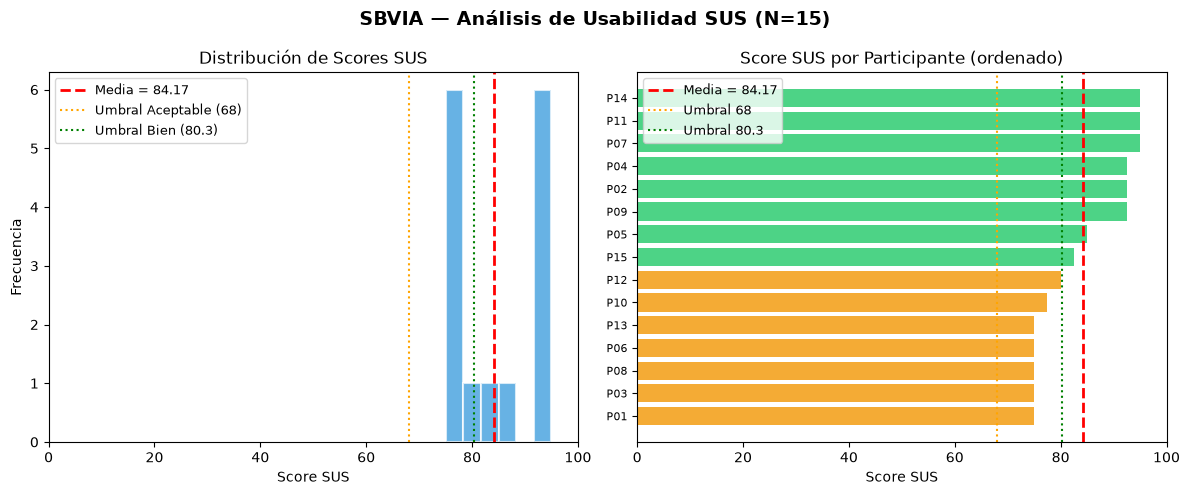

Figura guardada en: docs/mediciones/sus/sus-distribution.png


In [6]:
# Visualización: Histograma + curva KDE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('SBVIA — Análisis de Usabilidad SUS (N=15)', fontsize=14, fontweight='bold')

# Histograma
axes[0].hist(scores, bins=6, color='#3498db', alpha=0.75, edgecolor='white', linewidth=1.5)
axes[0].axvline(x=mean, color='red', linestyle='--', linewidth=2, label=f'Media = {mean:.2f}')
axes[0].axvline(x=68, color='orange', linestyle=':', linewidth=1.5, label='Umbral Aceptable (68)')
axes[0].axvline(x=80.3, color='green', linestyle=':', linewidth=1.5, label='Umbral Bien (80.3)')
axes[0].set_xlabel('Score SUS')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Scores SUS')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 100)

# Score por participante (ordenado)
sorted_data = df.sort_values('sus_calculado')
colors = ['#e74c3c' if s < 68 else '#f39c12' if s < 80.3 else '#2ecc71' for s in sorted_data['sus_calculado']]
axes[1].barh(range(n), sorted_data['sus_calculado'], color=colors, alpha=0.85)
axes[1].axvline(x=mean, color='red', linestyle='--', linewidth=2, label=f'Media = {mean:.2f}')
axes[1].axvline(x=68, color='orange', linestyle=':', linewidth=1.5, label='Umbral 68')
axes[1].axvline(x=80.3, color='green', linestyle=':', linewidth=1.5, label='Umbral 80.3')
axes[1].set_yticks(range(n))
axes[1].set_yticklabels(sorted_data['participant_id'], fontsize=8)
axes[1].set_xlabel('Score SUS')
axes[1].set_title('Score SUS por Participante (ordenado)')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.savefig('../docs/mediciones/sus/sus-distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada en: docs/mediciones/sus/sus-distribution.png')

In [7]:
# Resumen final para el informe
print('=== RESUMEN PARA INFORME ACADÉMICO ===')
print(f'  Media SUS     : {mean:.2f} / 100')
print(f'  DT            : {std:.2f}')
print(f'  IC 95% (t)    : [{ci[0]:.2f}, {ci[1]:.2f}]')
print(f'  Clasificación : {clasificar_sus(mean)}')
print(f'  N             : {n} participantes')
print(f'  Fuente        : sus-raw-data.csv (datos anónimos, consentimiento informado)')

=== RESUMEN PARA INFORME ACADÉMICO ===
  Media SUS     : 84.17 / 100
  DT            : 8.64
  IC 95% (t)    : [79.38, 88.95]
  Clasificación : Bien+ (B+)
  N             : 15 participantes
  Fuente        : sus-raw-data.csv (datos anónimos, consentimiento informado)
